# <font color="blue">**Solar Research**</font>

In [1]:
import sys
# Local Anaconda: keep NumPy 1.x, pandas and matplotlib as installed (pip then picks a compatible sunpy 7.x)
LOCAL_PINS = "" if "google.colab" in sys.modules else "'numpy<2' 'pandas<2.3' 'matplotlib<3.10'"
%pip install -q "sunpy[net,map,timeseries]" {LOCAL_PINS}
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.timeseries import LombScargle
from astropy.visualization import ImageNormalize, AsinhStretch, LogStretch

import sunpy.map
import sunpy.timeseries as ts
from sunpy.coordinates import frames
from sunpy.net import Fido, attrs as a, hek

plt.rcParams["figure.figsize"] = (9, 4)
pd.set_option("display.max_columns", None)

Note: you may need to restart the kernel to use updated packages.


<font color="blue">*Pipeline: from the 11-year solar cycle to a single flare in X-rays, extreme UV and the magnetic field*</font>

The Sun is the only star whose surface can be resolved in detail. This notebook recovers the activity cycle from 275 years of sunspot counts, picks a flare from an event catalogue, measures its GOES class from the raw X-ray light curve and locates it in SDO images. The structure follows the other notebooks: catalogue → selection → raw data → own measurement → comparison with the catalogue.

| Cell | What it does | Database |
|---|---|---|
| Setup | Installs `sunpy` (net, map, timeseries). In a local Anaconda kernel it keeps NumPy < 2, pandas < 2.3 and matplotlib < 3.10, so pip picks sunpy 7.x and upgrades no installed package | – |
| 1. Solar cycle | Monthly sunspot number since 1749, 13-month smoothed curve, numbered cycle maxima, Lomb–Scargle periodogram | SILSO (Royal Observatory of Belgium) |
| 2. Flare catalogue | Flares ≥ M5.0 in 2024 with GOES class, NOAA active region and position. Map of the positions on the disk, histogram of heliographic latitudes, Top-K table | **HEK** (Heliophysics Event Knowledgebase, SSW Latest Events) |
| 3. GOES light curve | `SELECTED_PEAK = "2024-10-03 12:18"`: X-ray flux at 0.5–4 Å and 1–8 Å. GOES class from the peak flux, rise and decay time | **GOES XRS** (NOAA) via `sunpy.net.Fido` |
| 4. SDO full disk | Five full-disk images at the flare peak: AIA 171, 131, 304 and 1600 Å and the HMI magnetogram, with the catalogue position marked | **SDO AIA / HMI** (NASA) via VSO |
| 5. Active-region zoom | 300″ cut-outs with HMI polarity contours. Own flare position from the brightest point in AIA 131 Å, converted to heliographic coordinates and compared with the catalogue | – |

**Own measurements vs. catalogue.** Three quantities are measured from raw data and checked against reference values (example: X9.0 flare of 2024-10-03, the strongest of cycle 25):

* **Cycle length:** the Lomb–Scargle peak lies at 11.00 years; the mean interval between maxima is 10.98 ± 1.92 years (range 7.3–17.0). Reference: ~11 years (Schwabe cycle). The latest maximum is cycle 25 in 2024.8 with a smoothed sunspot number of 161.
* **GOES class:** X8.8 from the 1-minute averaged 1–8 Å flux of GOES-18, against X9.0 in the catalogue. The difference is about 2 %.
* **Flare position:** the brightest point in AIA 131 Å lies at S16W05, the catalogue gives S15W03; offset 41″ ≈ 30,000 km. A flare is an extended structure (the ribbons span ~100″), while the catalogue stores a single point, so offsets of a few tens of arcseconds are expected.

The latitude histogram in step 2 shows the two activity belts at roughly 10–25° north and south of the equator (Spörer's law); in 2024 the southern belt produced more large flares.

Notes:

* **Runtime:** the five SDO images (~7 MB each) take 1–3 min; sunpy stores them in `~/sunpy/data` and reuses them.
* **Saturation:** at the peak of large flares AIA 171 Å saturates and shows vertical bleeding stripes. AIA switches to short exposures during flares, so the full-disk images are shown in DN/s and binned 4×4 to reduce photon noise.
* **Other flares:** any peak time from the table in step 2 works. SDO data start in May 2010; for other years change `START` / `END` in step 2.
* **Magnetogram:** HMI images are stored rotated by 180°; the notebook rotates them to solar north up.

✅ 3332 monthly values from 1749 to 2026.6


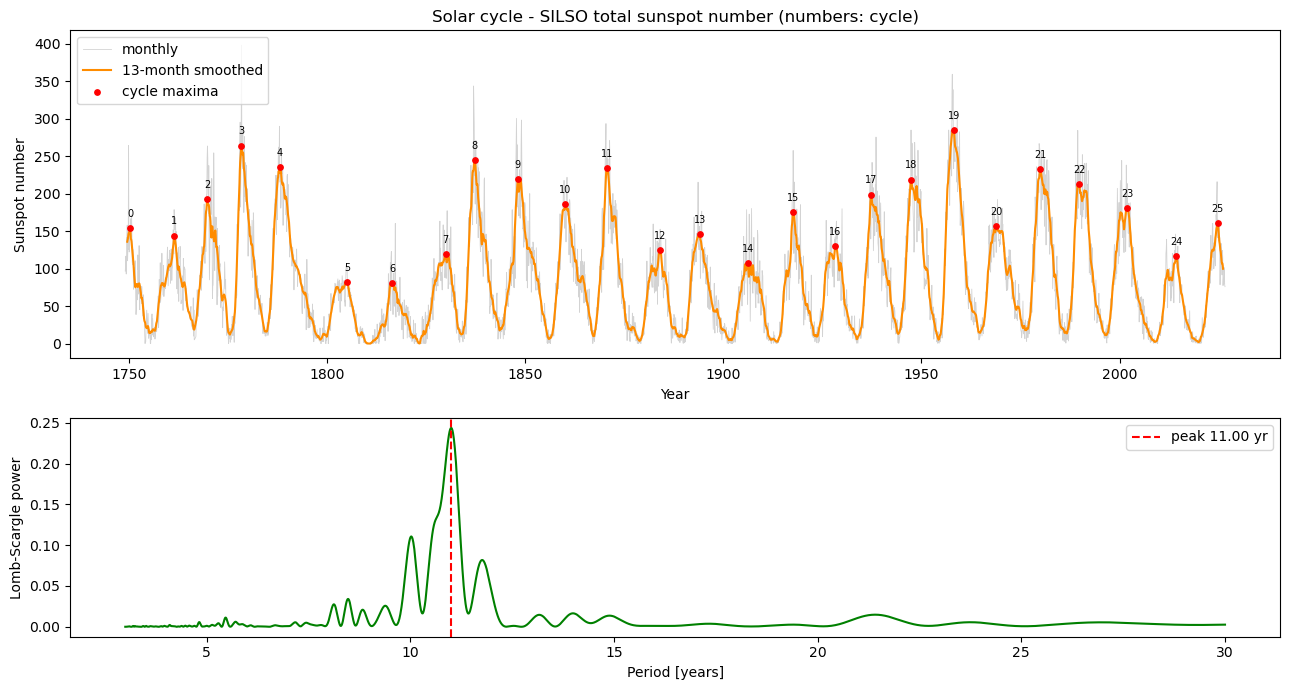

✅ Periodogram peak:       11.00 years
   Mean interval of maxima: 10.98 ± 1.92 years  (range 7.3-17.0)
   Literature value:        ~11 years (Schwabe cycle); magnetic Hale cycle ~22 years
   Latest maximum:          cycle 25, 2024.8, smoothed SN = 161


In [2]:
# 1. Solar cycle: monthly sunspot number since 1749 (SILSO, Royal Observatory of Belgium)
# Goal: recover the ~11-year Schwabe cycle from the raw record
SILSO_URL = "https://www.sidc.be/SILSO/INFO/snmtotcsv.php"

sn_df = pd.read_csv(SILSO_URL, sep=";", header=None,
                    names=["year", "month", "decimal_year", "sn", "sn_std", "n_obs", "provisional"])
sn_df = sn_df[sn_df["sn"] >= 0].reset_index(drop=True)                     # -1 = missing value
print(f"✅ {len(sn_df)} monthly values from {sn_df['decimal_year'].min():.0f} to {sn_df['decimal_year'].max():.1f}")

# 13-month smoothed sunspot number (standard SILSO definition: tapered running mean, half weight at both ends)
w = np.r_[0.5, np.ones(11), 0.5] / 12
sn_df["sn_smooth"] = np.convolve(sn_df["sn"], w, mode="same")
sn_df.loc[:5, "sn_smooth"] = np.nan
sn_df.loc[len(sn_df) - 6:, "sn_smooth"] = np.nan

# Cycle maxima = peaks of the smoothed curve (at least 7 years apart)
peaks, _ = find_peaks(sn_df["sn_smooth"].fillna(0), distance=7 * 12, prominence=30)
maxima = sn_df.loc[peaks, ["decimal_year", "sn_smooth"]].reset_index(drop=True)
# Official numbering: cycle 1 peaked in 1761 (the record starts in 1749, near the maximum of "cycle 0")
maxima.index = maxima.index + 1 - int((maxima["decimal_year"] < 1755).sum())
maxima["interval_yr"] = maxima["decimal_year"].diff()

# Lomb-Scargle periodogram of the raw monthly series
freq = np.linspace(1 / 30, 1 / 3, 5000)                                       # 3 ... 30 years
power = LombScargle(sn_df["decimal_year"], sn_df["sn"]).power(freq)
P_cycle = 1 / freq[np.argmax(power)]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={"height_ratios": [3, 2]})
axes[0].plot(sn_df["decimal_year"], sn_df["sn"], c="lightgrey", lw=0.6, label="monthly")
axes[0].plot(sn_df["decimal_year"], sn_df["sn_smooth"], c="darkorange", lw=1.5, label="13-month smoothed")
axes[0].scatter(maxima["decimal_year"], maxima["sn_smooth"], c="red", s=15, zorder=3, label="cycle maxima")
for n, row in maxima.iterrows():
    axes[0].text(row["decimal_year"], row["sn_smooth"] + 15, str(n), ha="center", fontsize=7)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Sunspot number")
axes[0].set_title("Solar cycle - SILSO total sunspot number (numbers: cycle)")
axes[0].legend(loc="upper left")
axes[1].plot(1 / freq, power, c="green")
axes[1].axvline(P_cycle, color="red", ls="--", label=f"peak {P_cycle:.2f} yr")
axes[1].set_xlabel("Period [years]")
axes[1].set_ylabel("Lomb-Scargle power")
axes[1].legend()
fig.tight_layout()
plt.show()

# Print results
print(f"✅ Periodogram peak:       {P_cycle:.2f} years")
print(f"   Mean interval of maxima: {maxima['interval_yr'].mean():.2f} ± {maxima['interval_yr'].std():.2f} years  "
      f"(range {maxima['interval_yr'].min():.1f}-{maxima['interval_yr'].max():.1f})")
print(f"   Literature value:        ~11 years (Schwabe cycle); magnetic Hale cycle ~22 years")
last = maxima.iloc[-1]
print(f"   Latest maximum:          cycle {maxima.index[-1]}, {last['decimal_year']:.1f}, smoothed SN = {last['sn_smooth']:.0f}")

 ✅ 143 flares >= M5.0 between 2024-01-01 and 2024-12-31 (HEK / SSW Latest Events)

 ✅ Flares per GOES class


fl_goescls
M    91
X    52
Name: count, dtype: int64

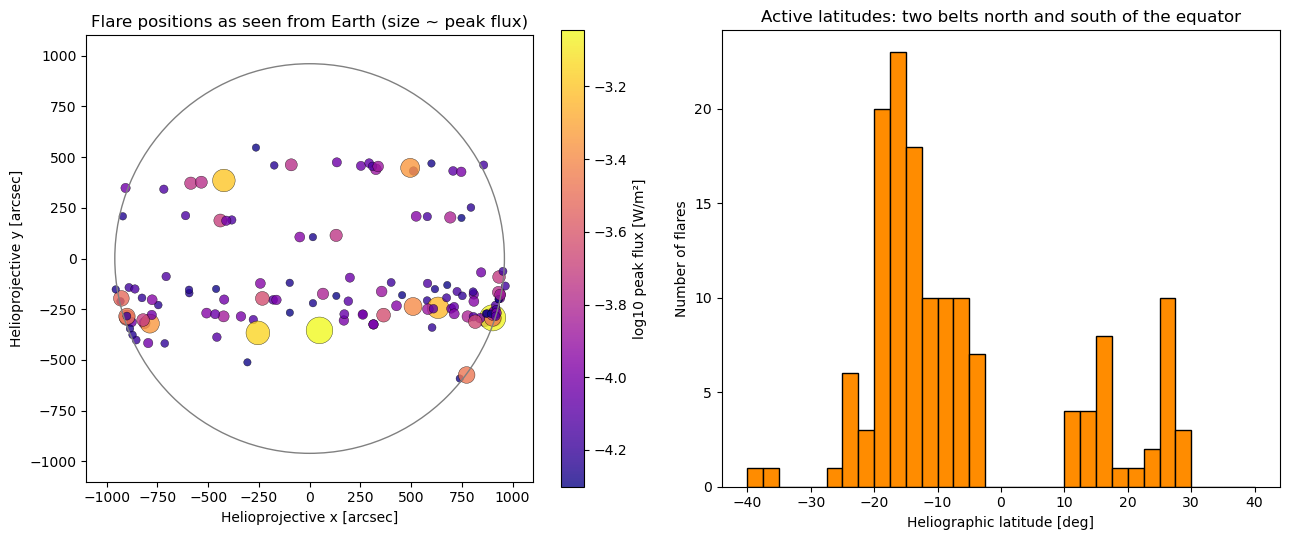


 ✅ Top-K strongest flares


,event_peaktime,fl_goescls,ar_noaanum,hpc_x,hpc_y,hgs_y,hgs_x
112,2024-10-03 12:18:00,X9.0,13842,48.664053,-353.997204,-15,3
55,2024-05-14 16:51:00,X8.7,13664,902.279400,-292.158780,-18,89
111,2024-10-01 22:20:00,X7.1,13842,-254.893320,-366.558462,-16,-16
9,2024-02-22 22:34:00,X6.4,13590,-422.507478,384.594816,17,-27
46,2024-05-11 01:23:00,X5.8,13664,632.784000,-242.817216,-17,44
109,2024-09-14 15:29:00,X4.5,13825,-787.304580,-320.647080,-16,-59
31,2024-05-06 06:35:00,X4.5,13663,495.753540,446.794224,25,35
44,2024-05-10 06:54:00,X4.0,13664,509.721894,-236.440206,-17,34
56,2024-05-15 08:37:00,X3.5,13664,902.156880,-292.156578,-18,89
3,2024-02-09 13:14:00,X3.4,13575,773.830680,-573.874506,-37,85


In [3]:
# 2. Load flare catalogue from the Heliophysics Event Knowledgebase (HEK, LMSAL / NASA SDO)
# Goal: strongest flares of a period, their GOES class and position on the solar disk
START, END = "2024-01-01", "2024-12-31"   # 2024 = maximum of solar cycle 25
MIN_CLASS  = "M5.0"                       # GOES class threshold (A < B < C < M < X, factor 10 each)

def goes_flux(cls):
    """GOES class string ('X9.0') -> peak 1-8 Å flux [W/m^2]."""
    return {"A": 1e-8, "B": 1e-7, "C": 1e-6, "M": 1e-5, "X": 1e-4}[cls[0]] * float(cls[1:])

def goes_class(flux):
    """Peak 1-8 Å flux [W/m^2] -> GOES class string."""
    for letter, base in [("X", 1e-4), ("M", 1e-5), ("C", 1e-6), ("B", 1e-7), ("A", 1e-8)]:
        if flux >= base:
            return f"{letter}{flux / base:.1f}"
    return "<A1"

hek_client = hek.HEKClient()
result = hek_client.search(a.Time(START, END), a.hek.EventType("FL"),
                           a.hek.FL.GOESCls >= MIN_CLASS, a.hek.FRM.Name == "SSW Latest Events")
COLUMNS = ["event_starttime", "event_peaktime", "event_endtime", "fl_goescls", "ar_noaanum",
           "hpc_x", "hpc_y", "hgs_x", "hgs_y"]
flares_df = result[COLUMNS].to_pandas()
flares_df["peak_flux"] = flares_df["fl_goescls"].map(goes_flux)
# NOAA active-region numbers passed 10000 in 2002; SSW stores only the last 4 digits
flares_df["ar_noaanum"] = np.where((flares_df["ar_noaanum"] > 0) & (flares_df["ar_noaanum"] < 10000),
                                   flares_df["ar_noaanum"] + 10000, flares_df["ar_noaanum"])
flares_df = flares_df.sort_values("event_peaktime").reset_index(drop=True)
print(f" ✅ {len(flares_df)} flares >= {MIN_CLASS} between {START} and {END} (HEK / SSW Latest Events)")

print("\n ✅ Flares per GOES class")
display(flares_df["fl_goescls"].str[0].value_counts())

# Flare positions: active latitudes (Spörer's law) and disk distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sc = axes[0].scatter(flares_df["hpc_x"], flares_df["hpc_y"], c=np.log10(flares_df["peak_flux"]),
                     s=8 + 4e5 * flares_df["peak_flux"], cmap="plasma", alpha=0.8, edgecolor="k", lw=0.3)
axes[0].add_patch(plt.Circle((0, 0), 960, fill=False, color="grey"))
axes[0].set_aspect("equal")
axes[0].set_xlim(-1100, 1100)
axes[0].set_ylim(-1100, 1100)
axes[0].set_xlabel("Helioprojective x [arcsec]")
axes[0].set_ylabel("Helioprojective y [arcsec]")
axes[0].set_title("Flare positions as seen from Earth (size ~ peak flux)")
fig.colorbar(sc, ax=axes[0], label="log10 peak flux [W/m²]")
axes[1].hist(flares_df["hgs_y"], bins=np.arange(-40, 41, 2.5), color="darkorange", edgecolor="k")
axes[1].set_xlabel("Heliographic latitude [deg]")
axes[1].set_ylabel("Number of flares")
axes[1].set_title("Active latitudes: two belts north and south of the equator")
fig.tight_layout()
plt.show()

print("\n ✅ Top-K strongest flares")
K = 10
top_k = flares_df.sort_values("peak_flux", ascending=False).head(K)
top_k[["event_peaktime", "fl_goescls", "ar_noaanum", "hpc_x", "hpc_y", "hgs_y", "hgs_x"]]

✅ Flare:          X9.0   peak 2024-10-03 12:18:00
Start / end:       2024-10-03 12:08:00  ->  2024-10-03 12:27:00
Active region:     NOAA 13842
Position:          x = 49", y = -354"  (latitude -15 deg, longitude +3 deg)

2 GOES XRS files found, satellites [16, 18]


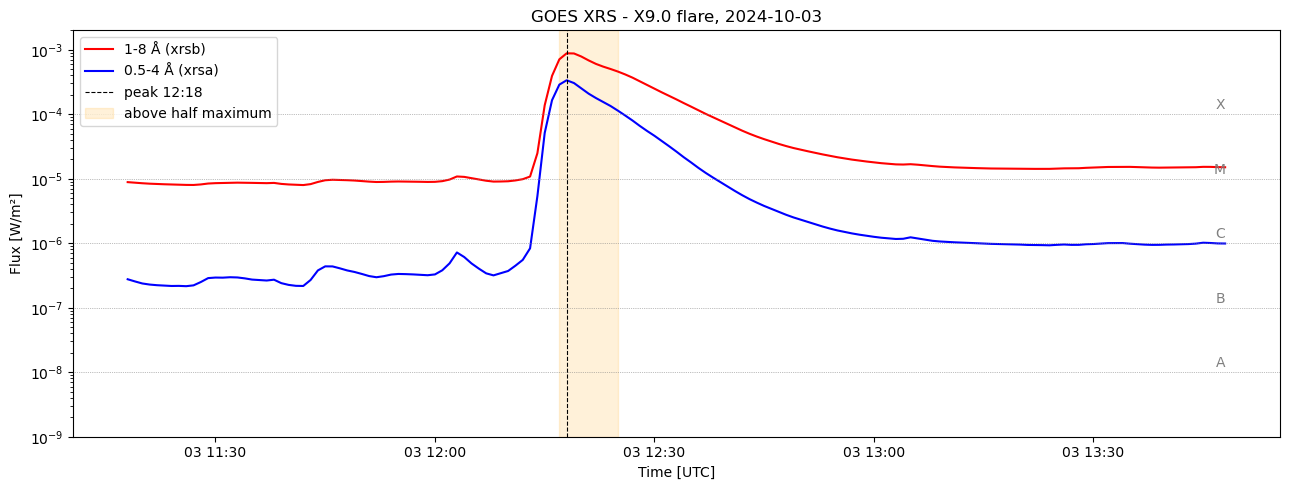

✅ GOES class from the light curve
  Peak 1-8 Å flux:   8.81e-04 W/m²  at 12:18 UTC  ->  class X8.8
  Catalogue class:   X9.0
  Rise / decay:      1 min / 7 min above half maximum (1-min resolution)
  Hardness xrsa/xrsb at peak: 0.38  (higher = hotter plasma)


In [4]:
# 3. Select flare, load GOES X-ray light curve and determine the GOES class ourselves
SELECTED_PEAK = "2024-10-03 12:18"   # <- Enter a peak time from the table above (X9.0 = strongest flare of cycle 25)
WINDOW = (1.0, 1.5)                  # hours before / after the peak

dt = (pd.to_datetime(flares_df["event_peaktime"]) - pd.Timestamp(SELECTED_PEAK)).abs()
if dt.min() > pd.Timedelta("10min"):
    raise ValueError(f"No flare in the catalogue within 10 min of {SELECTED_PEAK}.")
flare = flares_df.loc[dt.idxmin()]
peak = Time(flare["event_peaktime"])
t0, t1 = peak - WINDOW[0] * u.hour, peak + WINDOW[1] * u.hour

print(f"✅ Flare:          {flare['fl_goescls']}   peak {flare['event_peaktime']}")
print(f"Start / end:       {flare['event_starttime']}  ->  {flare['event_endtime']}")
print(f"Active region:     NOAA {flare['ar_noaanum']}")
print(f"Position:          x = {flare['hpc_x']:.0f}\", y = {flare['hpc_y']:.0f}\"  "
      f"(latitude {flare['hgs_y']:+.0f} deg, longitude {flare['hgs_x']:+.0f} deg)")

# GOES XRS: 0.5-4 Å (xrsa) and 1-8 Å (xrsb); the GOES class is defined by the 1-8 Å peak flux
search = Fido.search(a.Time(t0.iso, t1.iso), a.Instrument("XRS"), a.Resolution("avg1m"))
print(f"\n{len(search[0])} GOES XRS files found, satellites {sorted(set(search[0]['SatelliteNumber']))}")
xrs_file = Fido.fetch(search[0][-1], progress=False)       # most recent satellite
goes = ts.TimeSeries(xrs_file[0]).truncate(t0.iso, t1.iso)
xrs = goes.to_dataframe()
xrs = xrs[(xrs["xrsb_quality"] == 0) & (xrs["xrsb"] > 0)]

i_peak = xrs["xrsb"].idxmax()
f_peak = xrs.loc[i_peak, "xrsb"]
f_bg = xrs["xrsb"].iloc[:15].median()                      # pre-flare background
half = f_bg + 0.5 * (f_peak - f_bg)
above = xrs.index[xrs["xrsb"] >= half]
rise = (i_peak - above[0]).total_seconds() / 60
decay = (above[-1] - i_peak).total_seconds() / 60

fig, ax = plt.subplots(figsize=(13, 5))
ax.semilogy(xrs.index, xrs["xrsb"], c="red", label="1-8 Å (xrsb)")
ax.semilogy(xrs.index, xrs["xrsa"], c="blue", label="0.5-4 Å (xrsa)")
for letter, level in [("A", 1e-8), ("B", 1e-7), ("C", 1e-6), ("M", 1e-5), ("X", 1e-4)]:
    ax.axhline(level, color="grey", lw=0.5, ls=":")
    ax.text(xrs.index[-1], level * 1.2, letter, ha="right", color="grey")
ax.axvline(i_peak, color="black", ls="--", lw=0.8, label=f"peak {i_peak:%H:%M}")
ax.axvspan(above[0], above[-1], color="orange", alpha=0.15, label="above half maximum")
ax.set_ylim(1e-9, 2e-3)
ax.set_xlabel("Time [UTC]")
ax.set_ylabel("Flux [W/m²]")
ax.set_title(f"GOES XRS - {flare['fl_goescls']} flare, {peak.datetime:%Y-%m-%d}")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

# Print results
print(f"✅ GOES class from the light curve")
print(f"  Peak 1-8 Å flux:   {f_peak:.2e} W/m²  at {i_peak:%H:%M} UTC  ->  class {goes_class(f_peak)}")
print(f"  Catalogue class:   {flare['fl_goescls']}")
print(f"  Rise / decay:      {rise:.0f} min / {decay:.0f} min above half maximum (1-min resolution)")
print(f"  Hardness xrsa/xrsb at peak: {xrs.loc[i_peak, 'xrsa'] / f_peak:.2f}  (higher = hotter plasma)")

✅ Downloading 5 full-disk images (4096x4096 px, ~7-15 MB each, 1-3 min)...
   AIA  171   2024-10-03 12:18:09
   AIA  131   2024-10-03 12:18:10
   AIA  304   2024-10-03 12:18:08
   AIA 1600   2024-10-03 12:18:14
   HMI        2024-10-03 12:18:30


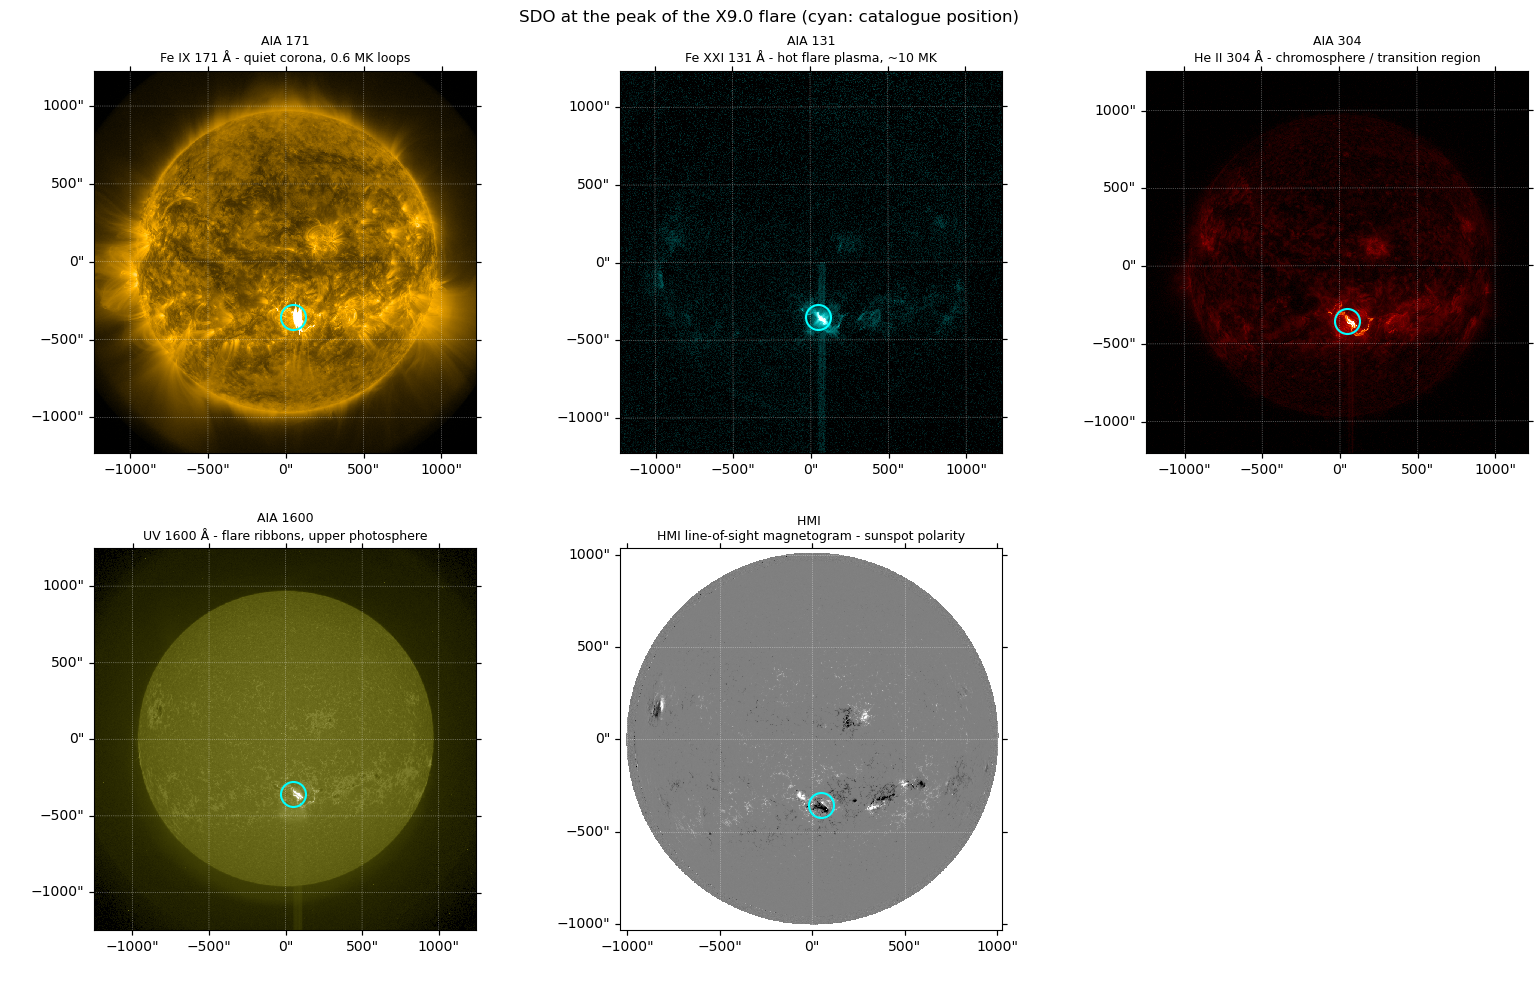

In [5]:
# 4. Load SDO images at the flare peak (AIA extreme-UV / UV and HMI magnetogram, via VSO)
CHANNELS = {
    ("AIA", 171):  "Fe IX 171 Å - quiet corona, 0.6 MK loops",
    ("AIA", 131):  "Fe XXI 131 Å - hot flare plasma, ~10 MK",
    ("AIA", 304):  "He II 304 Å - chromosphere / transition region",
    ("AIA", 1600): "UV 1600 Å - flare ribbons, upper photosphere",
    ("HMI", 0):    "HMI line-of-sight magnetogram - sunspot polarity",
}
# One combined query, downloaded in parallel; keep the first image of each channel
window = a.Time(peak.iso, (peak + 45 * u.s).iso)
aia_wl = a.Wavelength(171 * u.angstrom)
for (inst, wl) in list(CHANNELS)[1:]:
    if inst == "AIA":
        aia_wl = aia_wl | a.Wavelength(wl * u.angstrom)
search = Fido.search(window, (a.Instrument.aia & aia_wl) | (a.Instrument.hmi & a.Physobs.los_magnetic_field))
print(f"✅ Downloading {len(search)} full-disk images (4096x4096 px, ~7-15 MB each, 1-3 min)...")
files = Fido.fetch(*[block[:1] for block in search], progress=False)

maps = {}
for f in files:
    m = sunpy.map.Map(f)
    if m.detector == "HMI":
        key = ("HMI", 0)
        m = m.rotate(order=1)           # HMI is stored upside down (CROTA2 = 180 deg)
    else:
        key = ("AIA", int(m.wavelength.to_value(u.angstrom)))
    maps[key] = m
maps = {key: maps[key] for key in CHANNELS if key in maps}      # fixed panel order
for key, m in maps.items():
    print(f"   {key[0]} {key[1] or '':>4}   {m.date.iso[:19]}")

flare_coord = SkyCoord(flare["hpc_x"] * u.arcsec, flare["hpc_y"] * u.arcsec, frame=maps[("AIA", 171)].coordinate_frame)

fig = plt.figure(figsize=(16, 10))
for i, (key, m) in enumerate(maps.items()):
    small = m.superpixel([4, 4] * u.pix, func=np.mean)          # 4x4 binning averages out photon noise
    ax = fig.add_subplot(2, 3, i + 1, projection=small)
    if key[0] == "HMI":
        small.plot(axes=ax, cmap="gray", norm=plt.Normalize(-1000, 1000))
    else:
        small = small / m.exposure_time                          # DN/s: flare frames have much shorter exposures
        small.plot(axes=ax, norm=ImageNormalize(vmin=0, vmax=np.nanpercentile(small.data, 99.99),
                                                stretch=LogStretch(1000)))
    ax.plot_coord(flare_coord, "o", mfc="none", mec="cyan", ms=18, mew=1.5)
    ax.set_title(f"{key[0]} {key[1] or ''}\n{CHANNELS[key]}", fontsize=9)
    ax.coords[0].set_axislabel(" ")
    ax.coords[1].set_axislabel(" ")
fig.suptitle(f"SDO at the peak of the {flare['fl_goescls']} flare (cyan: catalogue position)", y=0.98)
fig.tight_layout()
plt.show()

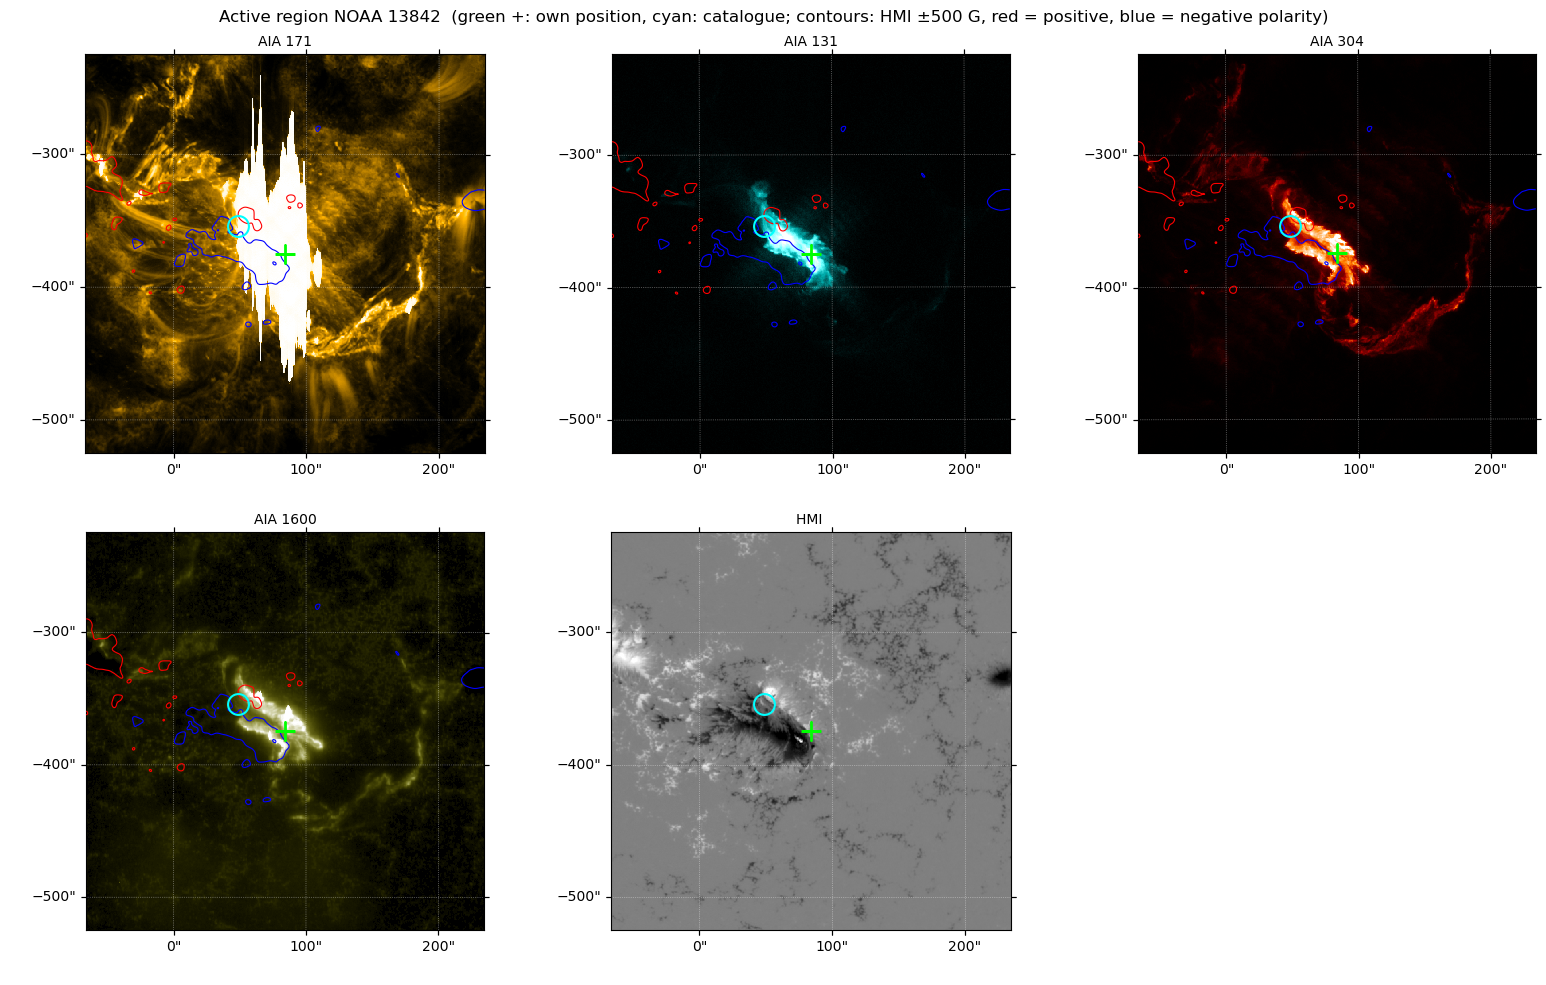

✅ Flare position
  Own (AIA 131 Å max):  x = 84", y = -375"   ->  S16W05
  Catalogue (HEK):      x = 49", y = -354"   ->  S15W03
  Offset:               41 arcsec  (1" ≈ 725 km on the Sun)  =  29,752 km
  Magnetic field (HMI): -1854 G ... +1888 G in the cut-out


In [6]:
# 5. Zoom into the active region and locate the flare ourselves
BOX = 300 * u.arcsec   # size of the cut-out
SMOOTH = 4             # Gaussian smoothing [pixels] before searching the brightest point (suppresses spikes)

# Own flare position: brightest point of the smoothed hot-plasma image (AIA 131 Å)
m131 = maps[("AIA", 131)]
data = gaussian_filter(np.nan_to_num(m131.data), SMOOTH)
iy, ix = np.unravel_index(np.argmax(data), data.shape)
own = m131.pixel_to_world(ix * u.pix, iy * u.pix)
own_hgs = own.transform_to(frames.HeliographicStonyhurst(obstime=m131.date))
offset = own.separation(flare_coord.transform_to(own.frame)).to(u.arcsec)

center = own
bl = SkyCoord(center.Tx - BOX / 2, center.Ty - BOX / 2, frame=center.frame)
tr = SkyCoord(center.Tx + BOX / 2, center.Ty + BOX / 2, frame=center.frame)
subs = {key: m.submap(bl, top_right=tr) for key, m in maps.items()}
hmi_sub = subs[("HMI", 0)]
hmi_smooth = sunpy.map.Map(gaussian_filter(np.nan_to_num(hmi_sub.data), 3), hmi_sub.meta)   # smoother contours

fig = plt.figure(figsize=(16, 10))
for i, (key, sub) in enumerate(subs.items()):
    ax = fig.add_subplot(2, 3, i + 1, projection=sub)
    if key[0] == "HMI":
        sub.plot(axes=ax, cmap="gray", norm=plt.Normalize(-1500, 1500))
    else:
        sub.plot(axes=ax, norm=ImageNormalize(sub.data, vmin=np.nanpercentile(sub.data, 1),
                                              vmax=np.nanpercentile(sub.data, 99.9), stretch=AsinhStretch(0.05)))
        hmi_smooth.draw_contours([-500, 500] * u.G, axes=ax, colors=["blue", "red"], linewidths=0.8)
    ax.plot_coord(own, "+", color="lime", ms=15, mew=2)
    ax.plot_coord(flare_coord, "o", mfc="none", mec="cyan", ms=15, mew=1.5)
    ax.set_title(f"{key[0]} {key[1] or ''}", fontsize=10)
    ax.coords[0].set_axislabel(" ")
    ax.coords[1].set_axislabel(" ")
fig.suptitle(f"Active region NOAA {flare['ar_noaanum']}  (green +: own position, cyan: catalogue; "
             f"contours: HMI ±500 G, red = positive, blue = negative polarity)", y=0.98)
fig.tight_layout()
plt.show()

# Print results
def stonyhurst_label(c):
    ns = "N" if c.lat >= 0 * u.deg else "S"
    ew = "W" if c.lon >= 0 * u.deg else "E"
    return f"{ns}{abs(c.lat.to_value(u.deg)):02.0f}{ew}{abs(c.lon.to_value(u.deg)):02.0f}"

cat_hgs = flare_coord.transform_to(frames.HeliographicStonyhurst(obstime=m131.date))
print(f"✅ Flare position")
print(f"  Own (AIA 131 Å max):  x = {own.Tx.to_value(u.arcsec):.0f}\", y = {own.Ty.to_value(u.arcsec):.0f}\"   ->  {stonyhurst_label(own_hgs)}")
print(f"  Catalogue (HEK):      x = {flare['hpc_x']:.0f}\", y = {flare['hpc_y']:.0f}\"   ->  {stonyhurst_label(cat_hgs)}")
print(f"  Offset:               {offset:.0f}  (1\" ≈ 725 km on the Sun)  =  {offset.to_value(u.arcsec) * 725:,.0f} km")
print(f"  Magnetic field (HMI): {np.nanmin(hmi_sub.data):.0f} G ... {np.nanmax(hmi_sub.data):+.0f} G in the cut-out")